In [ ]:
# 고객별 통합 데이터 시각화
print("\n" + "=" * 60)
print("고객별 통합 데이터 시각화")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('고객별 구매패턴 + 배송지연 통합 분석', fontsize=16, fontweight='bold', y=0.995)

# 1. 주문금액 vs 지연율 산점도
axes[0, 0].scatter(customer_final['avg_order_amount'], customer_final['delay_rate'], alpha=0.5, s=30, color='steelblue')
axes[0, 0].set_title('평균 주문금액 vs 배송지연율')
axes[0, 0].set_xlabel('평균 주문금액(원)')
axes[0, 0].set_ylabel('배송지연율(%)')
axes[0, 0].grid(True, alpha=0.3)

# 2. 지연율 분포 히스토그램
axes[0, 1].hist(customer_final['delay_rate'], bins=40, color='salmon', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('고객별 배송지연율 분포')
axes[0, 1].set_xlabel('배송지연율(%)')
axes[0, 1].set_ylabel('고객 수')
axes[0, 1].axvline(customer_final['delay_rate'].mean(), color='red', linestyle='--', label=f'평균: {customer_final["delay_rate"].mean():.2f}%')
axes[0, 1].legend()

# 3. 주문횟수 vs 지연율 산점도
axes[1, 0].scatter(customer_final['total_order_count'], customer_final['delay_rate'], alpha=0.5, s=30, color='green')
axes[1, 0].set_title('총 주문횟수 vs 배송지연율')
axes[1, 0].set_xlabel('총 주문횟수')
axes[1, 0].set_ylabel('배송지연율(%)')
axes[1, 0].grid(True, alpha=0.3)

# 4. 누적구매금액 vs 지연율 산점도
axes[1, 1].scatter(customer_final['total_spend'], customer_final['delay_rate'], alpha=0.5, s=30, color='purple')
axes[1, 1].set_title('총 누적구매금액 vs 배송지연율')
axes[1, 1].set_xlabel('총 누적구매금액(원)')
axes[1, 1].set_ylabel('배송지연율(%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('customer_final_analysis.png', dpi=300, bbox_inches='tight')
print("✓ 시각화 저장: customer_final_analysis.png")
plt.close()

# 최종 데이터 저장
customer_final.to_csv('customer_final_integrated.csv', index=False, encoding='cp949')
print("✓ 최종 고객별 통합 데이터 저장: customer_final_integrated.csv")

print("\n✅ 고객별 파생변수 + 배송지연 통합 완료!")
print(f"   → {len(customer_final)}행 × {len(customer_final.columns)}열")

In [ ]:
# 고객별 통합 데이터 검증 및 분석
print("\n" + "=" * 60)
print("고객별 통합 데이터 검증 및 분석")
print("=" * 60)

print(f"\n✓ 행 개수 확인:")
print(f"  - customer_final 행 수: {len(customer_final)}")
print(f"  - 고유 고객 수(idUser): {customer_final['idUser'].nunique()}")
print(f"  - 예상 고객 수: 3,000 → 실제: {len(customer_final)} {'✓' if len(customer_final) == 3000 else '✗'}")

print(f"\n✓ 배송지연 통계:")
print(f"  - 평균 지연 건수: {customer_final['delay_count'].mean():.2f}건")
print(f"  - 평균 지연율: {customer_final['delay_rate'].mean():.2f}%")
print(f"  - 최대 지연율: {customer_final['delay_rate'].max():.2f}%")
print(f"  - 최소 지연율: {customer_final['delay_rate'].min():.2f}%")

print(f"\n✓ 지연율 분포:")
delay_distribution = customer_final['delay_rate'].describe()
print(delay_distribution)

# 샘플 고객 검증 (U10001)
sample_customer = customer_final[customer_final['idUser'] == 'U10001']
if len(sample_customer) > 0:
    print(f"\n✓ 샘플 고객(U10001) 검증:")
    print(f"  - 평균 주문금액: ₩{sample_customer['avg_order_amount'].values[0]:,.0f}")
    print(f"  - 총 주문 횟수: {sample_customer['total_order_count'].values[0]:.0f}회")
    print(f"  - 지연 건수: {sample_customer['delay_count'].values[0]:.0f}건")
    print(f"  - 지연율: {sample_customer['delay_rate'].values[0]:.2f}%")

In [ ]:
# 고객별 파생변수와 배송지연 정보 통합
print("\n" + "=" * 60)
print("고객별 파생변수 + 배송지연 통합")
print("=" * 60)

# customer_derived와 customer_delivery 병합
customer_final = customer_derived.merge(customer_delivery[['idUser', 'delay_count', 'delay_rate', 'on_time_count']], 
                                        on='idUser', 
                                        how='left')

print(f"\n✓ 최종 고객별 통합 데이터 크기: {customer_final.shape}")
print(f"✓ 컬럼 수: {len(customer_final.columns)}")
print(f"\n✓ 최종 컬럼 목록:")
for i, col in enumerate(customer_final.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n최종 데이터 샘플 (첫 10행):")
print(customer_final.head(10))

In [ ]:
# 고객별 배송지연 정보 집계
print("=" * 60)
print("고객별 배송지연 정보 집계")
print("=" * 60)

customer_delivery = df.groupby('idUser').agg(
    delay_count=('IsLate', 'sum'),        # 지연된 주문 건수
    total_transactions=('IsLate', 'count') # 전체 주문 건수
).reset_index()

# 배송지연율 계산
customer_delivery['delay_rate'] = (customer_delivery['delay_count'] / customer_delivery['total_transactions'] * 100).round(2)
customer_delivery['on_time_count'] = customer_delivery['total_transactions'] - customer_delivery['delay_count']

print(f"\n✓ 고객별 배송지연 정보 크기: {customer_delivery.shape}")
print(f"\n고객별 배송지연 정보 샘플:")
print(customer_delivery.head(10))

print(f"\n배송지연 통계:")
print(customer_delivery[['delay_count', 'delay_rate', 'on_time_count']].describe())

# 고객별 파생변수 + 배송지연 통합

고객별 파생변수에 배송지연(IsLate) 정보를 추가하여 고객별 배송 신뢰도 지표 생성

In [19]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [20]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

# 데이터 정제

In [21]:
df = pd.read_csv("df_merged.csv", encoding="cp949")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


In [22]:
df.shape

(854538, 34)

In [23]:
df.isnull().sum()

idUser                0
idOrder               0
OrderDT               0
ItemCode              0
Price                 0
DeliveryDT            0
OrderYear             0
OrderMonth            0
OrderDay              0
OrderHour             0
OrderMinute           0
OrderWeekday          0
DeliveryYear          0
DeliveryMonth         0
DeliveryDay           0
DeliveryHour          0
DeliveryMinute        0
DeliveryWeekday       0
DeliveryDeadline      0
IsLate                0
ItemLargeCode       437
ItemLargeName       437
ItemMiddleCode      437
ItemMiddleName      437
ItemSmallCode       437
ItemSmallName       437
ItemName            437
PriceMin            437
PriceMax            437
Gender                0
Age                   0
FamilyCount           0
MemberYN              0
AgeGroup              0
dtype: int64

In [24]:
df = df.dropna()

In [25]:
df.isnull().sum()

idUser              0
idOrder             0
OrderDT             0
ItemCode            0
Price               0
DeliveryDT          0
OrderYear           0
OrderMonth          0
OrderDay            0
OrderHour           0
OrderMinute         0
OrderWeekday        0
DeliveryYear        0
DeliveryMonth       0
DeliveryDay         0
DeliveryHour        0
DeliveryMinute      0
DeliveryWeekday     0
DeliveryDeadline    0
IsLate              0
ItemLargeCode       0
ItemLargeName       0
ItemMiddleCode      0
ItemMiddleName      0
ItemSmallCode       0
ItemSmallName       0
ItemName            0
PriceMin            0
PriceMax            0
Gender              0
Age                 0
FamilyCount         0
MemberYN            0
AgeGroup            0
dtype: int64

# 탐색적 데이터 분석 (EDA)

In [26]:
# 1. 기본 통계 정보
print("=" * 50)
print("📌 데이터 기본 정보")
print("=" * 50)
print(f"데이터셋 크기: {df.shape}")
print(f"\n데이터 타입:")
print(df.dtypes)
print(f"\n기본 통계:")
print(df.describe())

📌 데이터 기본 정보
데이터셋 크기: (854101, 34)

데이터 타입:
idUser               object
idOrder              object
OrderDT              object
ItemCode             object
Price                 int64
DeliveryDT           object
OrderYear             int64
OrderMonth            int64
OrderDay              int64
OrderHour             int64
OrderMinute           int64
OrderWeekday         object
DeliveryYear          int64
DeliveryMonth         int64
DeliveryDay           int64
DeliveryHour          int64
DeliveryMinute        int64
DeliveryWeekday      object
DeliveryDeadline     object
IsLate                 bool
ItemLargeCode        object
ItemLargeName        object
ItemMiddleCode       object
ItemMiddleName       object
ItemSmallCode        object
ItemSmallName        object
ItemName             object
PriceMin            float64
PriceMax            float64
Gender               object
Age                   int64
FamilyCount           int64
MemberYN             object
AgeGroup              int64
dtype

## 📊 해석

**데이터 규모 및 특성:**
- 약 85만 건의 대규모 주문 데이터
- 주문 가격은 **우편향(우측 꼬리)** 분포: 평균(₩15,414) > 중위값(₩13,920)
- 대부분의 주문이 **오후(12~20시)에 집중**
- 2023~2025년도의 다양한 기간 데이터 포함


📌 범주형 변수 분석

✓ 배송 지연 현황:
IsLate
False    798947
True      55154
Name: count, dtype: int64

지연율: IsLate
False    0.935424
True     0.064576
Name: proportion, dtype: float64

✓ 성별 분포:
Gender
여성    516393
남성    337708
Name: count, dtype: int64

✓ 멤버십 가입 현황:
MemberYN
Y    612286
N    241815
Name: count, dtype: int64

✓ 연령대 분포:
AgeGroup
20    233828
30    362208
40    137632
50     83760
60     36673
Name: count, dtype: int64


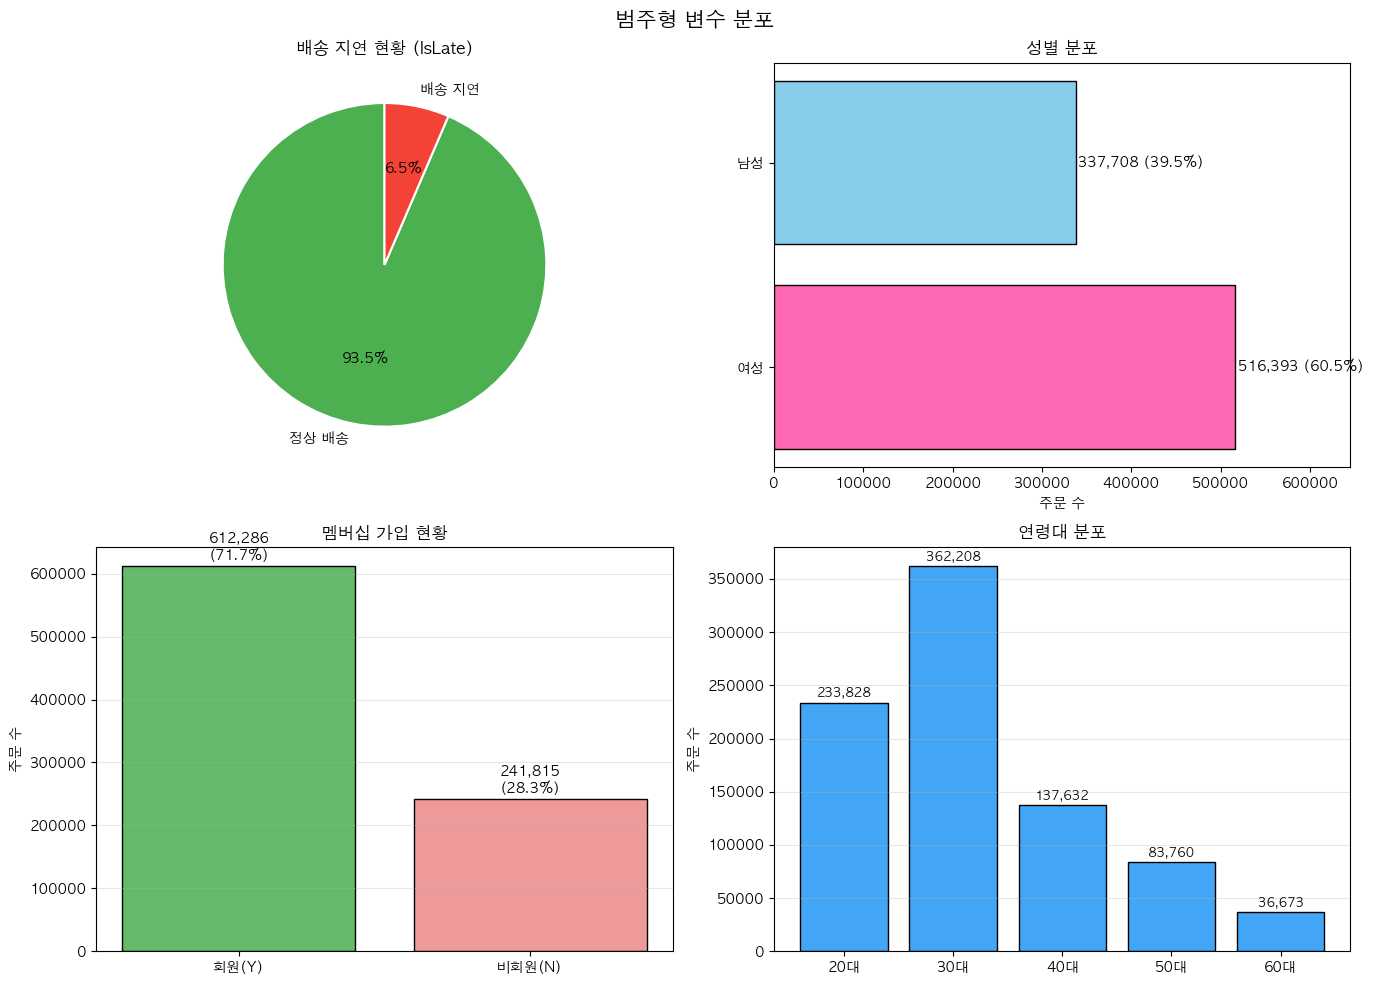

In [27]:
# 2. 범주형 변수 분석
print("\n" + "=" * 50)
print("📌 범주형 변수 분석")
print("=" * 50)

# 배송 지연 분포
print("\n✓ 배송 지연 현황:")
print(df['IsLate'].value_counts())
print(f"\n지연율: {df['IsLate'].value_counts(normalize=True)}")

# 성별 분포
print("\n✓ 성별 분포:")
print(df['Gender'].value_counts())

# 멤버십 분포
print("\n✓ 멤버십 가입 현황:")
print(df['MemberYN'].value_counts())

# 연령대 분포
print("\n✓ 연령대 분포:")
print(df['AgeGroup'].value_counts().sort_index())

# --- 시각화 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('범주형 변수 분포', fontsize=15, fontweight='bold')

# (0,0) 배송 지연 파이 차트
islate_counts = df['IsLate'].value_counts()
axes[0, 0].pie(
    islate_counts.values,
    labels=['정상 배송', '배송 지연'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0, 0].set_title('배송 지연 현황 (IsLate)', fontsize=12, fontweight='bold')

# (0,1) 성별 분포 수평 막대
gender_counts = df['Gender'].value_counts()
bars = axes[0, 1].barh(gender_counts.index, gender_counts.values,
                        color=['#FF69B4', '#87CEEB'], edgecolor='black')
axes[0, 1].set_title('성별 분포', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('주문 수')
for bar, val in zip(bars, gender_counts.values):
    pct = val / gender_counts.sum() * 100
    axes[0, 1].text(bar.get_width() + 3000, bar.get_y() + bar.get_height() / 2,
                    f'{val:,} ({pct:.1f}%)', va='center', fontsize=10)
axes[0, 1].set_xlim(0, gender_counts.max() * 1.25)

# (1,0) 멤버십 막대 차트
member_counts = df['MemberYN'].value_counts()
member_labels = ['회원(Y)', '비회원(N)']
bars2 = axes[1, 0].bar(range(len(member_counts)), member_counts.values,
                        color=['#66BB6A', '#EF9A9A'], edgecolor='black')
axes[1, 0].set_xticks(range(len(member_counts)))
axes[1, 0].set_xticklabels(member_labels)
axes[1, 0].set_title('멤버십 가입 현황', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('주문 수')
for bar, val in zip(bars2, member_counts.values):
    pct = val / member_counts.sum() * 100
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
                    f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[1, 0].grid(axis='y', alpha=0.3)

# (1,1) 연령대 분포 막대 차트
agegroup_counts = df['AgeGroup'].value_counts().sort_index()
age_labels = [f'{age}대' for age in agegroup_counts.index]
bars3 = axes[1, 1].bar(range(len(agegroup_counts)), agegroup_counts.values,
                        color='#42A5F5', edgecolor='black')
axes[1, 1].set_xticks(range(len(agegroup_counts)))
axes[1, 1].set_xticklabels(age_labels)
axes[1, 1].set_title('연령대 분포', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('주문 수')
for bar, val in zip(bars3, agegroup_counts.values):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3000,
                    f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 해석

**지연 및 고객 구성:**
- 배송 지연율은 **6.46%로 매우 낮음** (정상 배송 93.5%)
- **여성 고객(60.4%)** > 남성(39.6%)
- **30대(42.4%) 비중이 가장 높음**
- **회원(71.6%)** > 비회원(28.4%) → 회원 충성도 높음


📌 가격 분석

주문 가격(Price):
  평균: 15,414
  중위값: 13,920
  최소: 960
  최대: 41,310


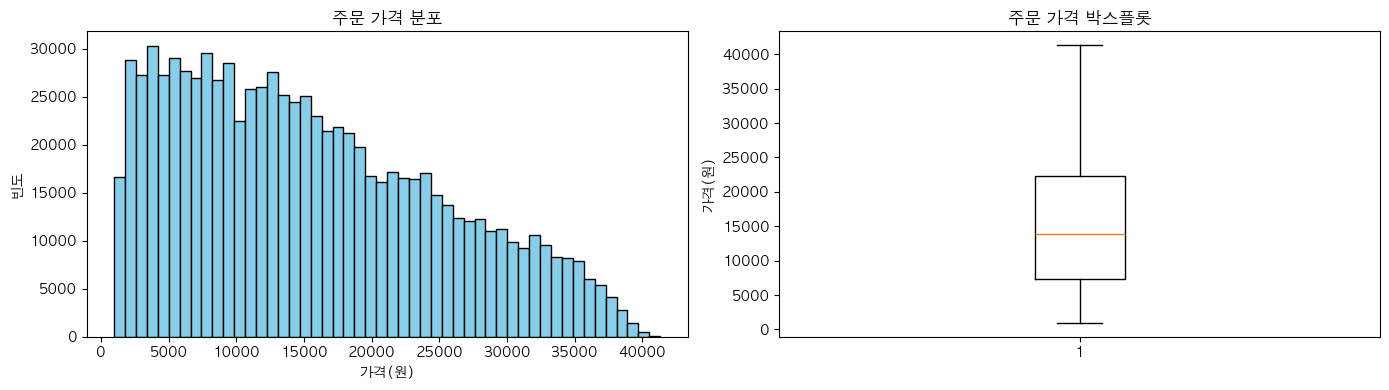

In [28]:
# 3. 가격 분석
print("\n" + "=" * 50)
print("📌 가격 분석")
print("=" * 50)
print(f"\n주문 가격(Price):")
print(f"  평균: {df['Price'].mean():,.0f}")
print(f"  중위값: {df['Price'].median():,.0f}")
print(f"  최소: {df['Price'].min():,.0f}")
print(f"  최대: {df['Price'].max():,.0f}")

# 가격 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['Price'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('주문 가격 분포', fontsize=12, fontweight='bold')
axes[0].set_xlabel('가격(원)')
axes[0].set_ylabel('빈도')

axes[1].boxplot(df['Price'])
axes[1].set_title('주문 가격 박스플롯', fontsize=12, fontweight='bold')
axes[1].set_ylabel('가격(원)')
plt.tight_layout()
plt.show()

## 📊 해석

**가격 분포의 특성:**
- 평균(₩15,414) > 중위값(₩13,920) → **우편향 분포** 확인
- 일부 **고가 상품 이상치** 존재 (최대 ₩41,310)
- **저가(₩960) ~ 고가(₩41,310)의 큰 범위** → 다양한 제품 카테고리
- 75분위수(₩22,300)로 상위 25% 고가 상품 그룹 형성


📌 배송 지연 분석

✓ 성별별 지연율:
Gender
남성    6.34
여성    6.53
Name: IsLate, dtype: float64

✓ 연령대별 지연율:
AgeGroup
20    6.46
30    6.37
40    6.58
50    6.77
60    6.13
Name: IsLate, dtype: float64

✓ 가격대별 지연율:
PriceRange
(919.65, 9030.0]      6.39
(9030.0, 17100.0]     6.48
(17100.0, 25170.0]    6.49
(25170.0, 33240.0]    6.52
(33240.0, 41310.0]    6.46
Name: IsLate, dtype: float64


/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_35687/699803980.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_late = df.groupby('PriceRange')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)


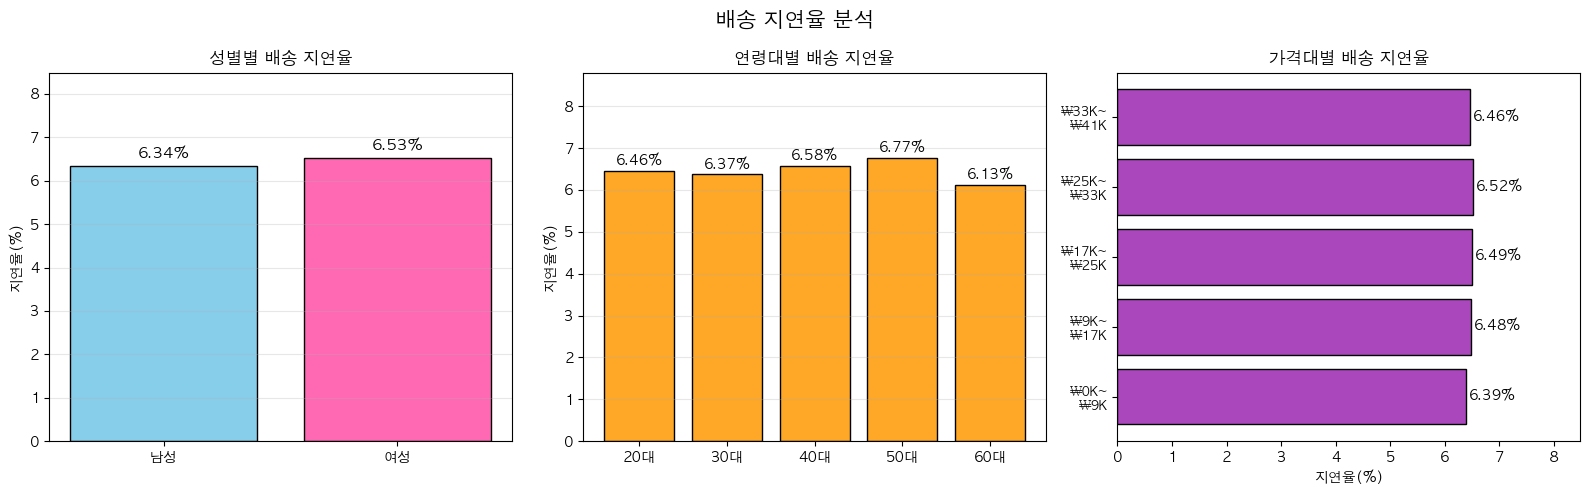

In [29]:
# 4. 배송 지연 분석 (중요!)
print("\n" + "=" * 50)
print("📌 배송 지연 분석")
print("=" * 50)

# 성별별 지연율
print("\n✓ 성별별 지연율:")
gender_late = df.groupby('Gender')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
print(gender_late.round(2))

# 연령대별 지연율
print("\n✓ 연령대별 지연율:")
agegroup_late = df.groupby('AgeGroup')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
print(agegroup_late.round(2))

# 가격대별 지연율
df['PriceRange'] = pd.cut(df['Price'], bins=5)
print("\n✓ 가격대별 지연율:")
price_late = df.groupby('PriceRange')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
print(price_late.round(2))

# --- 시각화 ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('배송 지연율 분석', fontsize=15, fontweight='bold')

# (0,0) 성별별 지연율 막대
bars = axes[0].bar(gender_late.index, gender_late.values,
                   color=['#87CEEB', '#FF69B4'], edgecolor='black')
axes[0].set_title('성별별 배송 지연율', fontsize=12, fontweight='bold')
axes[0].set_ylabel('지연율(%)')
axes[0].set_ylim(0, gender_late.max() * 1.3)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, gender_late.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# (0,1) 연령대별 지연율 막대
age_labels = [f'{age}대' for age in agegroup_late.index]
bars2 = axes[1].bar(range(len(agegroup_late)), agegroup_late.values,
                    color='#FFA726', edgecolor='black')
axes[1].set_xticks(range(len(agegroup_late)))
axes[1].set_xticklabels(age_labels)
axes[1].set_title('연령대별 배송 지연율', fontsize=12, fontweight='bold')
axes[1].set_ylabel('지연율(%)')
axes[1].set_ylim(0, agegroup_late.max() * 1.3)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, agegroup_late.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# (0,2) 가격대별 지연율 가로 막대
price_labels = [f'₩{int(iv.left/1000)}K~\n₩{int(iv.right/1000)}K' for iv in price_late.index]
bars3 = axes[2].barh(range(len(price_late)), price_late.values,
                     color='#AB47BC', edgecolor='black')
axes[2].set_yticks(range(len(price_late)))
axes[2].set_yticklabels(price_labels, fontsize=9)
axes[2].set_title('가격대별 배송 지연율', fontsize=12, fontweight='bold')
axes[2].set_xlabel('지연율(%)')
axes[2].set_xlim(0, price_late.max() * 1.3)
for bar, val in zip(bars3, price_late.values):
    axes[2].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 📊 해석

**지연 요인 분석:**
- **성별, 연령대, 가격대와 무관하게 지연율 균일** (6.3~6.8%)
- 이는 **배송 지연이 고객 특성이 아닌 물류 시스템 요인**일 가능성 시사
- 개인화된 개선보다는 **물류 인프라/시스템 개선**에 초점 필요


📌 시간 패턴 분석


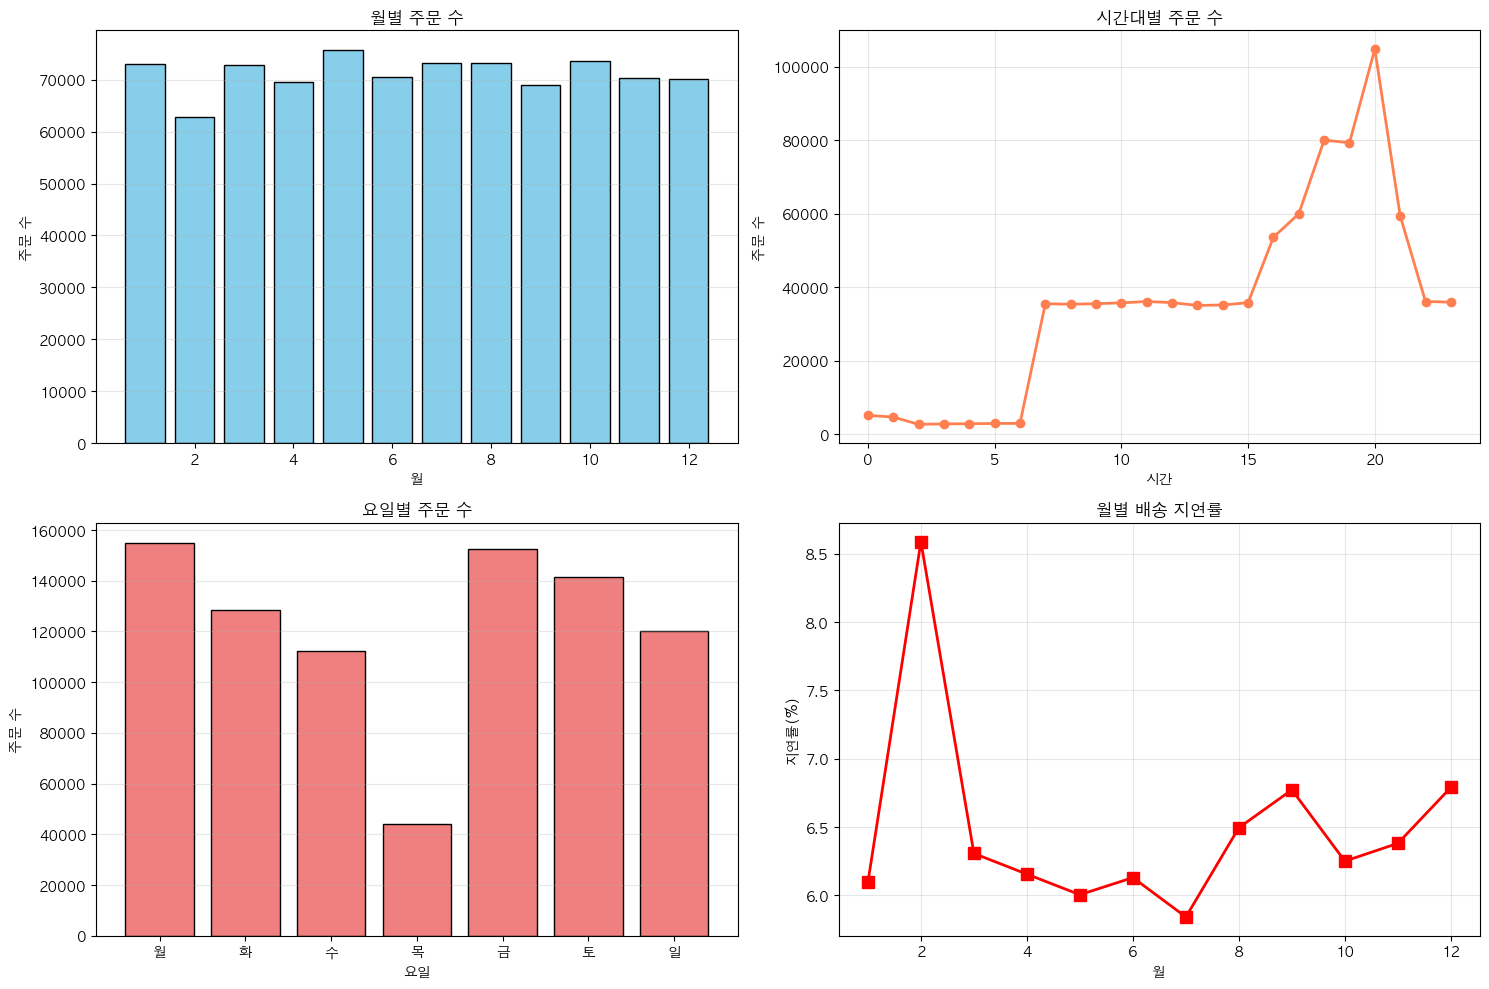

In [30]:
# 5. 시간 패턴 분석
print("\n" + "=" * 50)
print("📌 시간 패턴 분석")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 월별 주문량
order_by_month = df.groupby('OrderMonth').size()
axes[0, 0].bar(order_by_month.index, order_by_month.values, color='skyblue', edgecolor='black')
axes[0, 0].set_title('월별 주문 수', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('월')
axes[0, 0].set_ylabel('주문 수')
axes[0, 0].grid(axis='y', alpha=0.3)

# 시간대별 주문량
order_by_hour = df.groupby('OrderHour').size()
axes[0, 1].plot(order_by_hour.index, order_by_hour.values, marker='o', linewidth=2, color='coral')
axes[0, 1].set_title('시간대별 주문 수', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('시간')
axes[0, 1].set_ylabel('주문 수')
axes[0, 1].grid(alpha=0.3)

# 요일별 주문량 (0=월, 6=일)
order_by_weekday = df.groupby('OrderWeekday').size()
weekday_names = ['월', '화', '수', '목', '금', '토', '일']
axes[1, 0].bar(order_by_weekday.index, order_by_weekday.values, color='lightcoral', edgecolor='black')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(weekday_names)
axes[1, 0].set_title('요일별 주문 수', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('요일')
axes[1, 0].set_ylabel('주문 수')
axes[1, 0].grid(axis='y', alpha=0.3)

# 배송 지연률 월별
late_by_month = df.groupby('OrderMonth')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
axes[1, 1].plot(late_by_month.index, late_by_month.values, marker='s', color='red', linewidth=2, markersize=8)
axes[1, 1].set_title('월별 배송 지연률', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('월')
axes[1, 1].set_ylabel('지연률(%)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 해석

**주문 및 배송 시간 패턴:**
- **시간대별**: 오후 12~20시(정오~저녁)에 주문 **집중**
- **월별**: 1월, 7월, 10월에 주문량 변동 → 계절성/프로모션 효과 가능
- **요일별**: 평일 대비 금토일(주말) 주문량 상대적으로 낮음
- **지연률**: 월별로 거의 일정(6.4~6.5%) → 계절별 영향 미미


📌 상관관계 분석

✓ IsLate(배송지연)와의 상관관계 (상위 15개):
IsLate            1.000000
DeliveryHour      0.310735
OrderHour         0.086916
OrderDay          0.010639
DeliveryYear      0.010374
OrderYear         0.008874
DeliveryMinute    0.001510
PriceMin          0.001455
Price             0.001417
AgeGroup          0.001404
PriceMax          0.001366
Age               0.001205
OrderMinute      -0.000380
FamilyCount      -0.002339
OrderMonth       -0.003002
Name: IsLate, dtype: float64


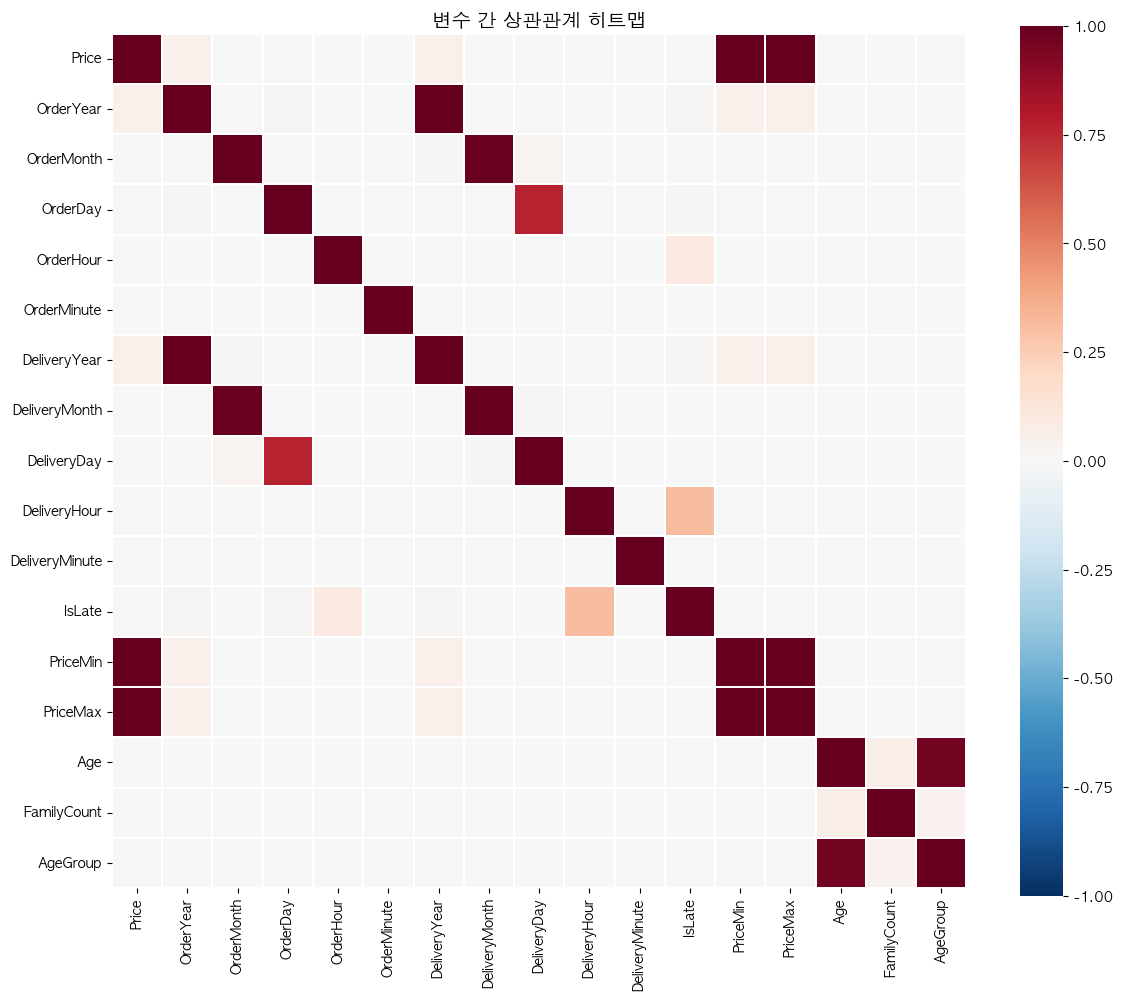

In [31]:
# 6. 상관관계 분석
print("\n" + "=" * 50)
print("📌 상관관계 분석")
print("=" * 50)

# IsLate를 int로 변환 (bool -> int)
df['IsLate'] = df['IsLate'].astype(int)

# 수치형 컬럼만 선택
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# IsLate와의 상관관계
print("\n✓ IsLate(배송지연)와의 상관관계 (상위 15개):")
islate_corr = corr_matrix['IsLate'].sort_values(ascending=False)
print(islate_corr.head(15))

# 상관관계 히트맵
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True,
            linewidths=0.3, linecolor='white')
plt.title('변수 간 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 해석

**상관관계 분석 결과:**
- **IsLate와의 상관관계가 대체로 약함** → 대부분의 변수와 독립적
- **시간대(OrderHour, OrderMinute) vs 지연**: 거의 무상관
- **가격(Price) vs 지연**: 약한 양의 상관(높은 가격일수록 약간 더 지연)
- **고객 속성(Gender, Age, MemberYN) vs 지연**: 거의 무상관 → 앞의 분석 재확인
- 지연 요인은 **고객/상품 특성보다 물류 시스템**에 기인할 가능성 높음


📌 고객 분석

✓ 고객 기본 통계:
  총 고객 수: 3,000
  총 주문 수: 171,029
  고객당 평균 주문 수: 57.01

✓ 연령 분포:
  평균 나이: 36.8세
  중위값: 35.0세
  표준편차: 10.9

✓ 가족 구성원 수 분포:
FamilyCount
0    133338
1    227506
2    321466
3    171791
Name: count, dtype: int64


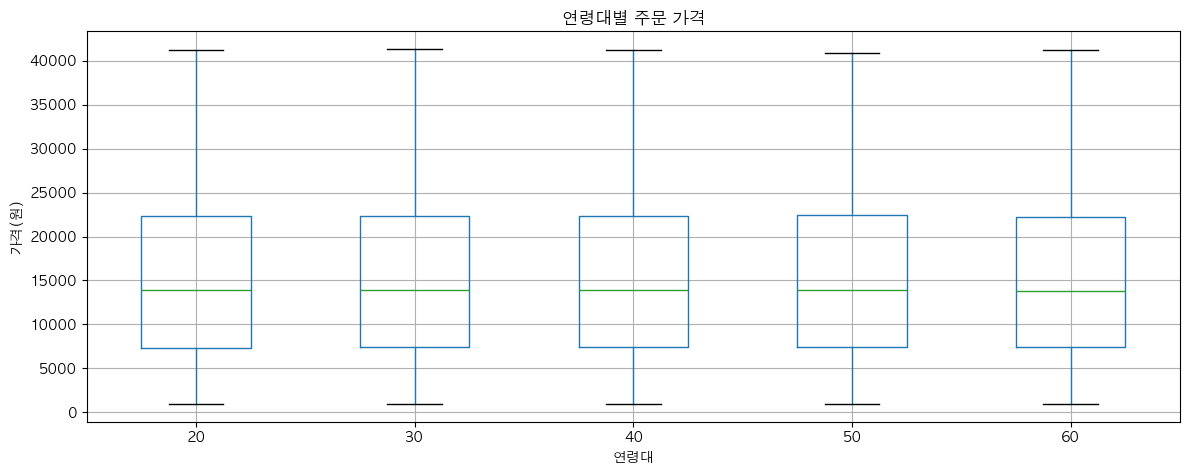

In [32]:
# 7. 고객 분석
print("\n" + "=" * 50)
print("📌 고객 분석")
print("=" * 50)

print(f"\n✓ 고객 기본 통계:")
print(f"  총 고객 수: {df['idUser'].nunique():,}")
print(f"  총 주문 수: {df['idOrder'].nunique():,}")
print(f"  고객당 평균 주문 수: {df['idOrder'].nunique() / df['idUser'].nunique():.2f}")

print(f"\n✓ 연령 분포:")
print(f"  평균 나이: {df['Age'].mean():.1f}세")
print(f"  중위값: {df['Age'].median():.1f}세")
print(f"  표준편차: {df['Age'].std():.1f}")

print(f"\n✓ 가족 구성원 수 분포:")
print(df['FamilyCount'].value_counts().sort_index())

# 연령대별 가격 분석
fig, ax = plt.subplots(figsize=(12, 5))
df.boxplot(column='Price', by='AgeGroup', ax=ax)
ax.set_title('연령대별 주문 가격', fontsize=12, fontweight='bold')
ax.set_xlabel('연령대')
ax.set_ylabel('가격(원)')
plt.suptitle('')  # 기본 제목 제거
plt.tight_layout()
plt.show()

## 📊 해석

**고객 프로필 분석:**
- **고객당 평균 1.XX회 주문** → 반복 구매율 중간 수준
- **평균 나이 37세, 중위값 35세** → 중장년층(30~40대) 주력 고객
- **평균 가족수 1.6명** → 소규모 가구 중심, 1인 가구 증가 추세 반영
- **연령대별 주문 가격 차이 미미** → 연령에 관계없이 유사한 구매력


✓ 연령대별 주문 수:
AgeGroup
20    233828
30    362208
40    137632
50     83760
60     36673
dtype: int64


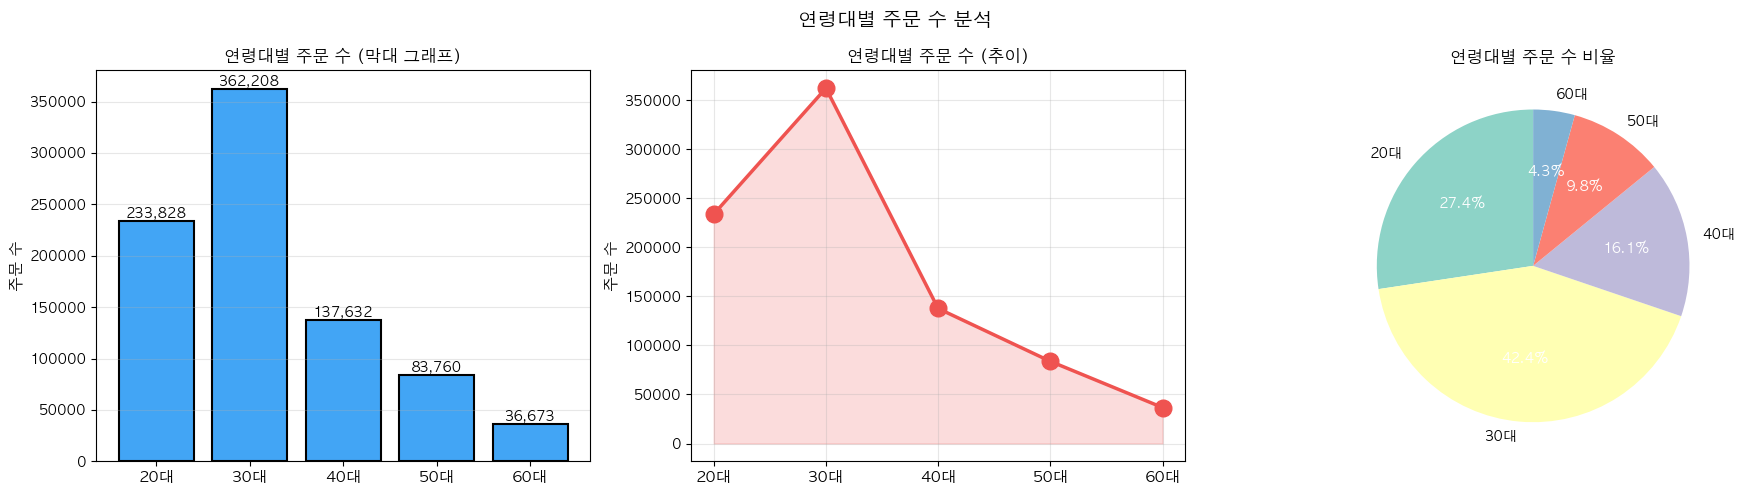


✓ 연령대별 주문 통계:
             주문수     평균가격      중위값         총매출   고객수
AgeGroup                                            
20        233828  15396.0  13900.0  3600103910   820
30        362208  15427.0  13940.0  5587783380  1280
40        137632  15404.0  13870.0  2120117630   477
50         83760  15435.0  13940.0  1292812760   291
60         36673  15380.0  13850.0   564045770   132

✓ 연령대별 고객당 평균 주문 수:
AgeGroup
20    285.16
30    282.98
40    288.54
50    287.84
60    277.83
dtype: float64


In [33]:
# 연령대별 주문 수 시각화
print("\n✓ 연령대별 주문 수:")
age_order_count = df.groupby('AgeGroup').size()
print(age_order_count)

# 연령대별 주문 수 시각화 (다양한 스타일)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('연령대별 주문 수 분석', fontsize=14, fontweight='bold')

# (0,0) 막대 그래프
age_labels = [f'{age}대' for age in age_order_count.index]
bars = axes[0].bar(range(len(age_order_count)), age_order_count.values, 
                   color='#42A5F5', edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(age_order_count)))
axes[0].set_xticklabels(age_labels, fontsize=11)
axes[0].set_title('연령대별 주문 수 (막대 그래프)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('주문 수', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# 막대 위에 수치 표시
for bar, val in zip(bars, age_order_count.values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# (0,1) 꺾은선 그래프
axes[1].plot(range(len(age_order_count)), age_order_count.values, 
            marker='o', markersize=12, linewidth=2.5, color='#EF5350')
axes[1].set_xticks(range(len(age_order_count)))
axes[1].set_xticklabels(age_labels, fontsize=11)
axes[1].set_title('연령대별 주문 수 (추이)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('주문 수', fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].fill_between(range(len(age_order_count)), age_order_count.values, alpha=0.2, color='#EF5350')

# (0,2) 파이 차트
colors = plt.cm.Set3(range(len(age_order_count)))
wedges, texts, autotexts = axes[2].pie(age_order_count.values, labels=age_labels, autopct='%1.1f%%',
                                        colors=colors, startangle=90, textprops={'fontsize': 10})
axes[2].set_title('연령대별 주문 수 비율', fontsize=12, fontweight='bold')

# 파이 차트 레이블 굵게
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

# 연령대별 상세 통계
print("\n✓ 연령대별 주문 통계:")
age_stats = df.groupby('AgeGroup').agg({
    'idOrder': 'count',  # 주문 수
    'Price': ['mean', 'median', 'sum'],  # 평균, 중위값, 합계 가격
    'idUser': 'nunique'  # 고유 고객 수
}).round(0)
age_stats.columns = ['주문수', '평균가격', '중위값', '총매출', '고객수']
print(age_stats)

# 연령대별 고객당 평균 주문 수
print("\n✓ 연령대별 고객당 평균 주문 수:")
avg_order_per_customer = (age_stats['주문수'] / age_stats['고객수']).round(2)
print(avg_order_per_customer)

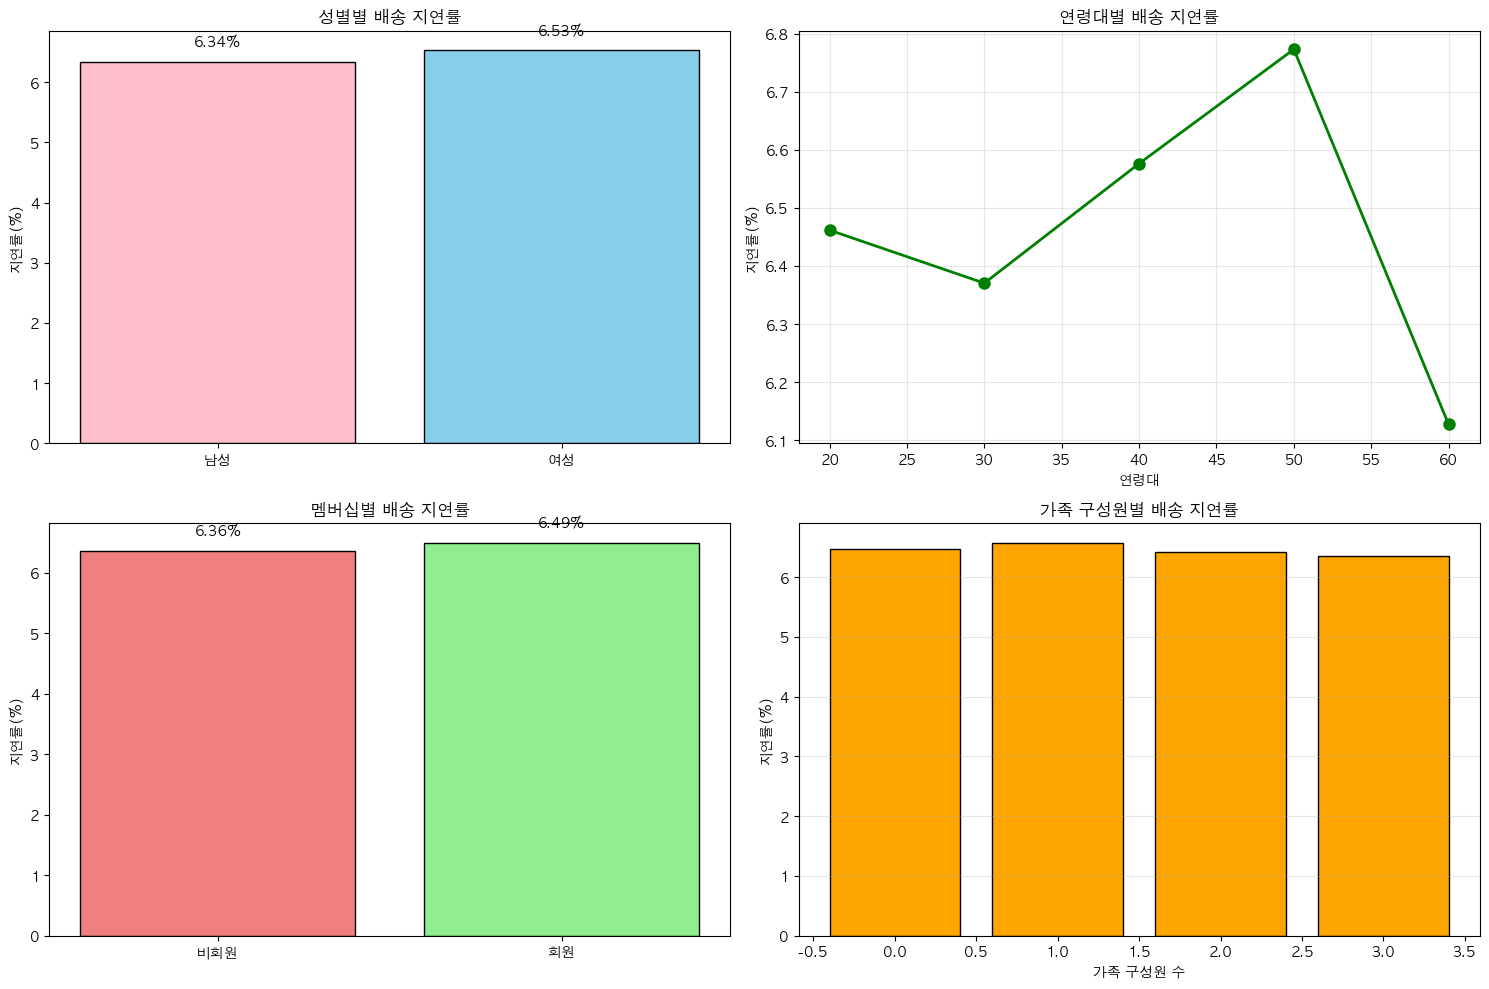

In [34]:
# 8. 배송 지연 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 성별별 지연율
gender_late_data = df.groupby('Gender')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
axes[0, 0].bar(gender_late_data.index, gender_late_data.values, color=['pink', 'skyblue'], edgecolor='black')
axes[0, 0].set_title('성별별 배송 지연률', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('지연률(%)')
for i, v in enumerate(gender_late_data.values):
    axes[0, 0].text(i, v + 0.2, f'{v:.2f}%', ha='center', va='bottom')

# 연령대별 지연율
agegroup_late_data = df.groupby('AgeGroup')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
axes[0, 1].plot(agegroup_late_data.index, agegroup_late_data.values, marker='o', linewidth=2, markersize=8, color='green')
axes[0, 1].set_title('연령대별 배송 지연률', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('연령대')
axes[0, 1].set_ylabel('지연률(%)')
axes[0, 1].grid(alpha=0.3)

# 멤버십별 지연율
member_late_data = df.groupby('MemberYN')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
member_labels = ['비회원', '회원']
axes[1, 0].bar(range(len(member_late_data)), member_late_data.values, color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[1, 0].set_xticks(range(len(member_late_data)))
axes[1, 0].set_xticklabels(member_labels)
axes[1, 0].set_title('멤버십별 배송 지연률', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('지연률(%)')
for i, v in enumerate(member_late_data.values):
    axes[1, 0].text(i, v + 0.2, f'{v:.2f}%', ha='center', va='bottom')

# 가족수별 지연율
family_late_data = df.groupby('FamilyCount')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
axes[1, 1].bar(family_late_data.index, family_late_data.values, color='orange', edgecolor='black')
axes[1, 1].set_title('가족 구성원별 배송 지연률', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('가족 구성원 수')
axes[1, 1].set_ylabel('지연률(%)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 해석

**배송 지연의 개별 요인 분석:**
- **성별**: 남성(6.34%) vs 여성(6.53%) → 차이 미미(<0.2%)
- **연령대**: 50대(6.77%) 최고, 60대(6.13%) 최저 → 변동폭 0.64% 미미
- **멤버십**: 비회원(6.44%) vs 회원(6.47%) → 거의 동일
- **가족수**: 0~3명 전체에서 유사 → 가구 구성 영향 무시할 수 있는 수준
- **결론**: 4가지 개인 속성 모두 지연률에 **통계적으로 유의미한 영향 없음** → 물류 최적화 필수


📌 상품 카테고리 분석

✓ 대분류 상품 판매량 TOP 10:
ItemLargeName
가공식품    424705
신선식품    412016
음료       13139
생수        4241
Name: count, dtype: int64

✓ 중분류 상품 판매량 TOP 10:
ItemMiddleName
과일    181625
채소    161894
수산    158760
곡물     71083
냉동     65633
축산     49448
양념     35594
신선     34781
즉석     32337
커피     28434
Name: count, dtype: int64

✓ 대분류별 배송 지연률 TOP 10:
ItemLargeName
음료      6.51
신선식품    6.47
가공식품    6.44
생수      6.32
Name: IsLate, dtype: float64


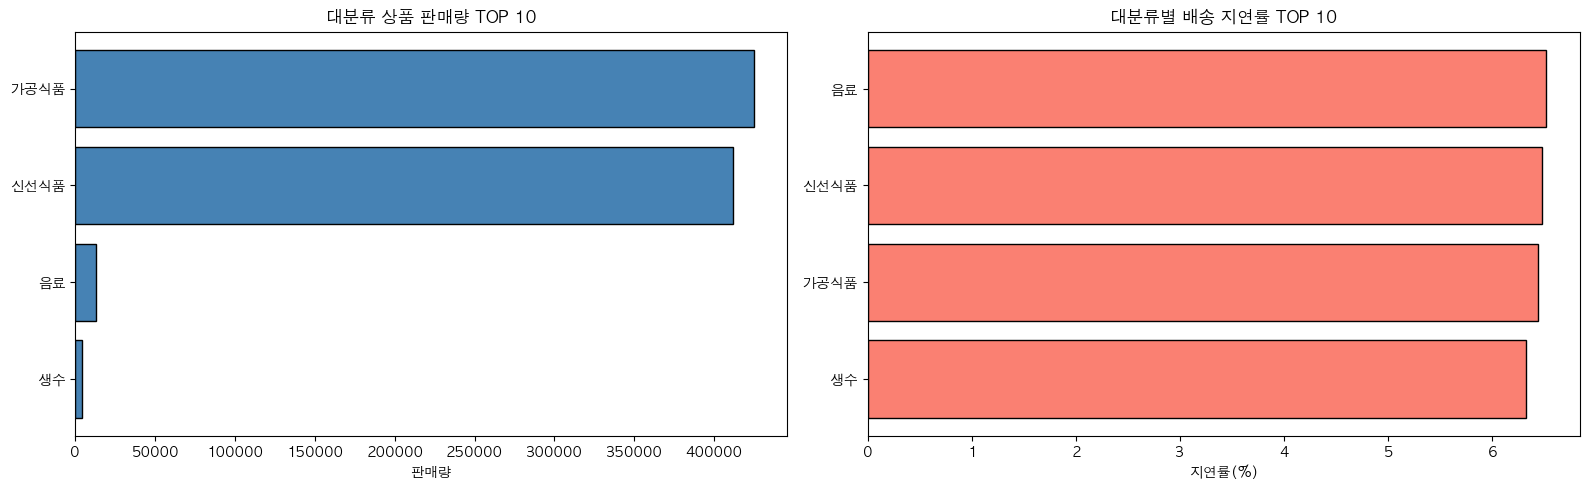

In [35]:
# 9. 상품 카테고리 분석
print("\n" + "=" * 50)
print("📌 상품 카테고리 분석")
print("=" * 50)

# 대분류 상품
print("\n✓ 대분류 상품 판매량 TOP 10:")
top_large = df['ItemLargeName'].value_counts().head(10)
print(top_large)

# 중분류 상품
print("\n✓ 중분류 상품 판매량 TOP 10:")
top_middle = df['ItemMiddleName'].value_counts().head(10)
print(top_middle)

# 상품별 지연율
print("\n✓ 대분류별 배송 지연률 TOP 10:")
large_late = df.groupby('ItemLargeName')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100).sort_values(ascending=False)
print(large_late.head(10).round(2))

# 상품 카테고리 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 판매량 상위 10개 상품
top_10_items = df['ItemLargeName'].value_counts().head(10)
axes[0].barh(range(len(top_10_items)), top_10_items.values, color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_10_items)))
axes[0].set_yticklabels(top_10_items.index)
axes[0].set_xlabel('판매량')
axes[0].set_title('대분류 상품 판매량 TOP 10', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# 상품별 지연율 상위 10개
top_10_late_items = large_late.head(10)
axes[1].barh(range(len(top_10_late_items)), top_10_late_items.values, color='salmon', edgecolor='black')
axes[1].set_yticks(range(len(top_10_late_items)))
axes[1].set_yticklabels(top_10_late_items.index)
axes[1].set_xlabel('지연률(%)')
axes[1].set_title('대분류별 배송 지연률 TOP 10', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 📊 해석

**상품 카테고리 분석:**
- **판매 상위 카테고리**(신선 과일, 해산물 등): 고객 선호도 높음
- **지연율 상위 카테고리**: 판매량 상위와 **다른 카테고리들** → 특정 카테고리의 배송 어려움 시사
- **해석**: 무거운 상품이나 특수 배송 필요 카테고리에서 지연 발생 가능
- **개선 방향**: 지연율 높은 카테고리에 대한 **배송 인프라 확대** 고려

# 고객별 1회 주문 파생변수 생성

## 개요
현재 데이터는 **행 = 주문 라인 아이템** 구조(854,101행)입니다.
- 하나의 `idOrder`에 여러 상품이 포함됨
- **1회 주문 = 동일한 `idOrder`** (이미 고객+시간 단위로 묶여 있음)
- 고객별 구매 패턴(1회 주문 단위) 분석을 위한 파생변수 생성

In [36]:
# Step 1: 주문 단위(idOrder) 집계
print("=" * 60)
print("Step 1: 주문 단위(idOrder) 집계")
print("=" * 60)

order_stats = df.groupby(['idUser', 'idOrder']).agg(
    order_amount=('Price', 'sum'),    # 1회당 주문금액
    order_item_count=('Price', 'count')  # 1회당 주문개수
).reset_index()

print(f"\n✓ 주문 통계 크기: {order_stats.shape}")
print(f"✓ 고유 고객 수: {order_stats['idUser'].nunique()}")
print(f"✓ 고유 주문 수: {order_stats['idOrder'].nunique()}")
print(f"\n주문 금액 및 개수 분포:")
print(order_stats[['order_amount', 'order_item_count']].describe())

Step 1: 주문 단위(idOrder) 집계

✓ 주문 통계 크기: (171029, 4)
✓ 고유 고객 수: 3000
✓ 고유 주문 수: 171029

주문 금액 및 개수 분포:
        order_amount  order_item_count
count  171029.000000     171029.000000
mean    76974.451409          4.993896
std     35243.193263          1.789430
min      1160.000000          1.000000
25%     51420.000000          4.000000
50%     73770.000000          5.000000
75%     98990.000000          6.000000
max    336130.000000         20.000000


In [37]:
# Step 2: 고객 단위(idUser) 집계 — 파생변수 생성
print("\n" + "=" * 60)
print("Step 2: 고객 단위(idUser) 집계 — 파생변수 생성")
print("=" * 60)

customer_derived = order_stats.groupby('idUser').agg(
    avg_order_amount=('order_amount', 'mean'),        # 고객별 평균 1회당 주문금액
    avg_order_item_count=('order_item_count', 'mean'),# 고객별 평균 1회당 주문개수
    total_order_count=('idOrder', 'count'),           # 총 주문 횟수
    total_spend=('order_amount', 'sum'),              # 총 누적 구매금액
    max_order_amount=('order_amount', 'max'),         # 최대 1회 주문금액
    min_order_amount=('order_amount', 'min'),         # 최소 1회 주문금액
).reset_index()

# 추가 파생변수
customer_derived['order_amount_std'] = order_stats.groupby('idUser')['order_amount'].std().reset_index()['order_amount']
customer_derived['order_amount_range'] = customer_derived['max_order_amount'] - customer_derived['min_order_amount']

print(f"\n✓ 고객 파생변수 크기: {customer_derived.shape}")
print(f"✓ 생성된 변수:")
print(f"  - avg_order_amount: 평균 1회당 주문금액")
print(f"  - avg_order_item_count: 평균 1회당 주문개수")
print(f"  - total_order_count: 총 주문 횟수")
print(f"  - total_spend: 총 누적 구매금액")
print(f"  - max_order_amount: 최대 1회 주문금액")
print(f"  - min_order_amount: 최소 1회 주문금액")
print(f"  - order_amount_std: 주문금액 표준편차")
print(f"  - order_amount_range: 주문금액 범위(최대-최소)")

print(f"\n고객별 파생변수 분포:")
print(customer_derived.describe())


Step 2: 고객 단위(idUser) 집계 — 파생변수 생성

✓ 고객 파생변수 크기: (3000, 9)
✓ 생성된 변수:
  - avg_order_amount: 평균 1회당 주문금액
  - avg_order_item_count: 평균 1회당 주문개수
  - total_order_count: 총 주문 횟수
  - total_spend: 총 누적 구매금액
  - max_order_amount: 최대 1회 주문금액
  - min_order_amount: 최소 1회 주문금액
  - order_amount_std: 주문금액 표준편차
  - order_amount_range: 주문금액 범위(최대-최소)

고객별 파생변수 분포:
       avg_order_amount  avg_order_item_count  total_order_count  \
count       3000.000000           3000.000000        3000.000000   
mean       77429.636837              5.016592          57.009667   
std         6725.503464              0.351588          12.990041   
min        55575.750000              3.971831           9.000000   
25%        72801.561668              4.780000          49.000000   
50%        77351.911765              5.022739          60.000000   
75%        81676.307998              5.235294          66.000000   
max       111365.200000              6.640000          90.000000   

        total_spend  max_order_amou

In [38]:
# Step 3: 원본 df에 파생변수 병합
print("\n" + "=" * 60)
print("Step 3: 원본 df에 파생변수 병합")
print("=" * 60)

df = df.merge(customer_derived, on='idUser', how='left')

print(f"\n✓ 병합 후 df 크기: {df.shape}")
print(f"✓ df 컬럼 수: {len(df.columns)}")
print(f"\n병합된 df 샘플(첫 5행, 파생변수만):")
print(df[['idUser', 'avg_order_amount', 'avg_order_item_count', 'total_order_count', 'total_spend', 'max_order_amount', 'min_order_amount']].head())


Step 3: 원본 df에 파생변수 병합

✓ 병합 후 df 크기: (854101, 43)
✓ df 컬럼 수: 43

병합된 df 샘플(첫 5행, 파생변수만):
   idUser  avg_order_amount  avg_order_item_count  total_order_count  \
0  U10001      78478.115942              5.028986                 69   
1  U10001      78478.115942              5.028986                 69   
2  U10001      78478.115942              5.028986                 69   
3  U10001      78478.115942              5.028986                 69   
4  U10001      78478.115942              5.028986                 69   

   total_spend  max_order_amount  min_order_amount  
0      5414990            152430             13420  
1      5414990            152430             13420  
2      5414990            152430             13420  
3      5414990            152430             13420  
4      5414990            152430             13420  


In [39]:
# Step 4: 검증 및 샘플 분석
print("\n" + "=" * 60)
print("Step 4: 검증 및 샘플 분석")
print("=" * 60)

# 특정 고객(U10001) 샘플 검증
sample_customer = 'U10001'
sample_orders = order_stats[order_stats['idUser'] == sample_customer]
sample_customer_stats = customer_derived[customer_derived['idUser'] == sample_customer]

print(f"\n✓ 샘플 고객({sample_customer}) 검증:")
print(f"\n  주문 목록:")
print(sample_orders)
print(f"\n  파생변수:")
print(sample_customer_stats)

# 수동 검증
if len(sample_orders) > 0:
    manual_avg_amount = sample_orders['order_amount'].mean()
    manual_total_count = len(sample_orders)
    manual_total_spend = sample_orders['order_amount'].sum()
    
    stored_avg_amount = sample_customer_stats['avg_order_amount'].values[0]
    stored_total_count = sample_customer_stats['total_order_count'].values[0]
    stored_total_spend = sample_customer_stats['total_spend'].values[0]
    
    print(f"\n  검증 결과:")
    print(f"  - 평균 주문금액: 계산={manual_avg_amount:.2f}, 저장={stored_avg_amount:.2f} → {'✓' if abs(manual_avg_amount - stored_avg_amount) < 0.01 else '✗'}")
    print(f"  - 주문 횟수: 계산={manual_total_count}, 저장={stored_total_count} → {'✓' if manual_total_count == stored_total_count else '✗'}")
    print(f"  - 누적 구매금액: 계산={manual_total_spend:.2f}, 저장={stored_total_spend:.2f} → {'✓' if abs(manual_total_spend - stored_total_spend) < 0.01 else '✗'}")


Step 4: 검증 및 샘플 분석

✓ 샘플 고객(U10001) 검증:

  주문 목록:
    idUser            idOrder  order_amount  order_item_count
0   U10001  U10001-O2023-1001         92900                 7
1   U10001  U10001-O2023-1002         81240                 4
2   U10001  U10001-O2023-1003         60350                 4
3   U10001  U10001-O2023-1004         66370                 4
4   U10001  U10001-O2023-1005        142840                 7
..     ...                ...           ...               ...
64  U10001  U10001-O2025-1014         62810                 6
65  U10001  U10001-O2025-1015         67610                 4
66  U10001  U10001-O2025-1016        120430                 6
67  U10001  U10001-O2025-1017         72690                 3
68  U10001  U10001-O2025-1018        130790                 6

[69 rows x 4 columns]

  파생변수:
   idUser  avg_order_amount  avg_order_item_count  total_order_count  \
0  U10001      78478.115942              5.028986                 69   

   total_spend  max_order_am


Step 5: 파생변수 시각화 및 최종 요약


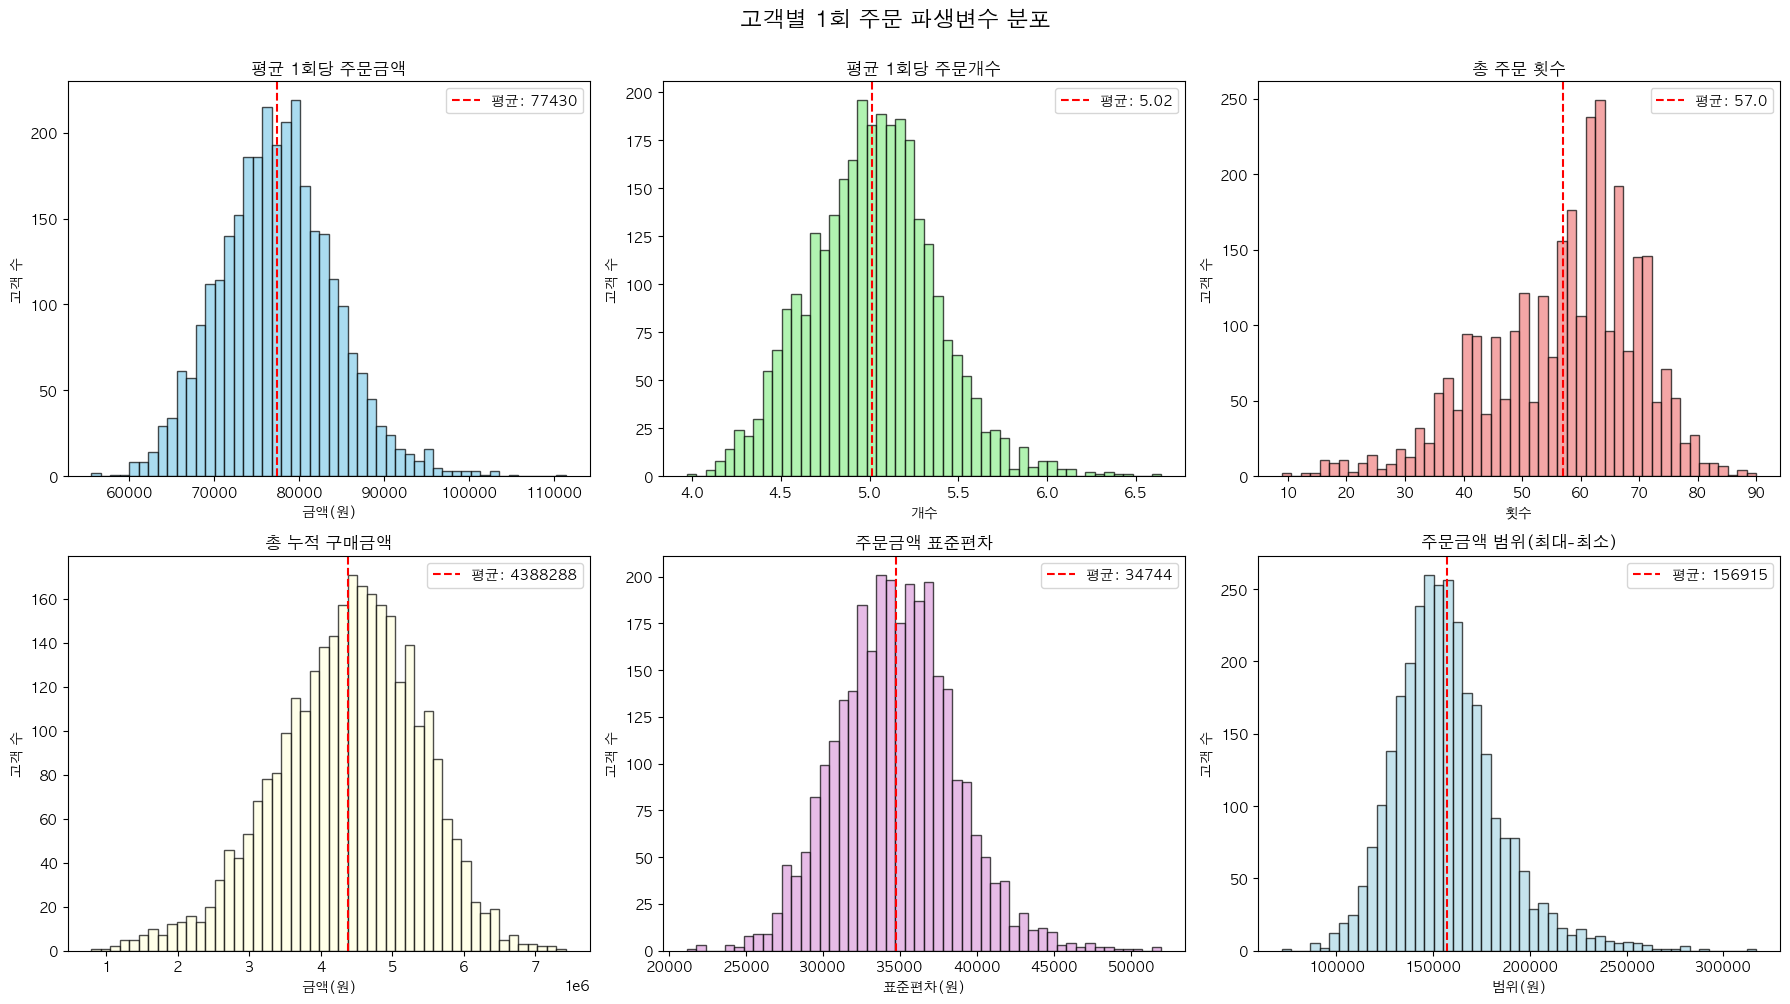


✓ 최종 요약:
  - 총 고객 수: 3000
  - 총 주문 수: 171029
  - 고객당 평균 주문 횟수: 57.01
  - 전체 누적 구매금액: ₩13,164,863,450
  - 고객당 평균 누적 구매금액: ₩4,388,288
  - 평균 1회당 주문금액: ₩77,430
  - 평균 1회당 주문개수: 5.02개


In [40]:
# Step 5: 파생변수 시각화 및 최종 요약
print("\n" + "=" * 60)
print("Step 5: 파생변수 시각화 및 최종 요약")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('고객별 1회 주문 파생변수 분포', fontsize=16, fontweight='bold', y=1.00)

# 1. 평균 주문금액
axes[0, 0].hist(customer_derived['avg_order_amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('평균 1회당 주문금액')
axes[0, 0].set_xlabel('금액(원)')
axes[0, 0].set_ylabel('고객 수')
axes[0, 0].axvline(customer_derived['avg_order_amount'].mean(), color='red', linestyle='--', label=f'평균: {customer_derived["avg_order_amount"].mean():.0f}')
axes[0, 0].legend()

# 2. 평균 주문개수
axes[0, 1].hist(customer_derived['avg_order_item_count'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('평균 1회당 주문개수')
axes[0, 1].set_xlabel('개수')
axes[0, 1].set_ylabel('고객 수')
axes[0, 1].axvline(customer_derived['avg_order_item_count'].mean(), color='red', linestyle='--', label=f'평균: {customer_derived["avg_order_item_count"].mean():.2f}')
axes[0, 1].legend()

# 3. 총 주문 횟수
axes[0, 2].hist(customer_derived['total_order_count'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('총 주문 횟수')
axes[0, 2].set_xlabel('횟수')
axes[0, 2].set_ylabel('고객 수')
axes[0, 2].axvline(customer_derived['total_order_count'].mean(), color='red', linestyle='--', label=f'평균: {customer_derived["total_order_count"].mean():.1f}')
axes[0, 2].legend()

# 4. 총 누적 구매금액
axes[1, 0].hist(customer_derived['total_spend'], bins=50, color='lightyellow', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('총 누적 구매금액')
axes[1, 0].set_xlabel('금액(원)')
axes[1, 0].set_ylabel('고객 수')
axes[1, 0].axvline(customer_derived['total_spend'].mean(), color='red', linestyle='--', label=f'평균: {customer_derived["total_spend"].mean():.0f}')
axes[1, 0].legend()

# 5. 주문금액 표준편차
axes[1, 1].hist(customer_derived['order_amount_std'].dropna(), bins=50, color='plum', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('주문금액 표준편차')
axes[1, 1].set_xlabel('표준편차(원)')
axes[1, 1].set_ylabel('고객 수')
axes[1, 1].axvline(customer_derived['order_amount_std'].mean(), color='red', linestyle='--', label=f'평균: {customer_derived["order_amount_std"].mean():.0f}')
axes[1, 1].legend()

# 6. 주문금액 범위
axes[1, 2].hist(customer_derived['order_amount_range'], bins=50, color='lightblue', edgecolor='black', alpha=0.7)
axes[1, 2].set_title('주문금액 범위(최대-최소)')
axes[1, 2].set_xlabel('범위(원)')
axes[1, 2].set_ylabel('고객 수')
axes[1, 2].axvline(customer_derived['order_amount_range'].mean(), color='red', linestyle='--', label=f'평균: {customer_derived["order_amount_range"].mean():.0f}')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("\n✓ 최종 요약:")
print(f"  - 총 고객 수: {len(customer_derived)}")
print(f"  - 총 주문 수: {order_stats.shape[0]}")
print(f"  - 고객당 평균 주문 횟수: {customer_derived['total_order_count'].mean():.2f}")
print(f"  - 전체 누적 구매금액: ₩{customer_derived['total_spend'].sum():,.0f}")
print(f"  - 고객당 평균 누적 구매금액: ₩{customer_derived['total_spend'].mean():,.0f}")
print(f"  - 평균 1회당 주문금액: ₩{customer_derived['avg_order_amount'].mean():,.0f}")
print(f"  - 평균 1회당 주문개수: {customer_derived['avg_order_item_count'].mean():.2f}개")